In [1]:
import sys
from pathlib import Path

import os

# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))

import numpy as np
import matplotlib.pyplot as plt
from icecream import ic
from tqdm import tqdm

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)
from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

import pybigtools

c:\Users\michi\anaconda3\envs\genomics\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize(values):
    min_val = np.min(values)
    max_val = np.max(values)
    if max_val - min_val == 0:
        return np.zeros_like(values)  # Avoid division by zero
    return (values - min_val) / (max_val - min_val)

def selector(arr, start, end, same_size=True):
    if same_size:
        result = np.zeros_like(arr)
        result[start:end] = arr[start:end]
        return result
    else:
        return arr[start:end]

def copy(arr, target, start):
    copy = np.zeros_like(arr)
    copy[start:start+len(target)] = target
    return copy

In [3]:
dyad_1 = pybigtools.open(r"C:\Users\michi\Documents\Leiden_Universiteit\Research Project\Project Jon\Data\GSM2561057_Dyads_H3_CC_rep_1.bw")
dyad_2 = pybigtools.open(r"C:\Users\michi\Documents\Leiden_Universiteit\Research Project\Project Jon\Data\GSM2561058_Dyads_H3_CC_rep_2.bw")
dyad_3 = pybigtools.open(r"C:\Users\michi\Documents\Leiden_Universiteit\Research Project\Project Jon\Data\GSM2561059_Dyads_H3_CC_rep_3.bw")

occupancy_1 = pybigtools.open(r"C:\Users\michi\Documents\Leiden_Universiteit\Research Project\Project Jon\Data\GSM2561057_Occupancy_H3_CC_rep_1.bw")
occupancy_2 = pybigtools.open(r"C:\Users\michi\Documents\Leiden_Universiteit\Research Project\Project Jon\Data\GSM2561058_Occupancy_H3_CC_rep_2.bw")
occupancy_3 = pybigtools.open(r"C:\Users\michi\Documents\Leiden_Universiteit\Research Project\Project Jon\Data\GSM2561059_Occupancy_H3_CC_rep_3.bw")

chrom_number="II"

chromosome = f"chr{chrom_number}"


values_occ_1 = occupancy_1.values(chromosome)  # Get values for a specific region
values_dyad_1 = dyad_1.values(chromosome)  # Get values for a specific region

values_occ_2 = occupancy_2.values(chromosome)  # Get values for a specific region
values_dyad_2 = dyad_2.values(chromosome)  # Get values for a specific region

values_occ_3 = occupancy_3.values(chromosome)  # Get values for a specific region
values_dyad_3 = dyad_3.values(chromosome)

In [4]:
chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = 12_000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = 272500
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)



Selected chromosome: .genomes\sacCer3, chrII  len=813184


In [ ]:
print(np.sum(values_occ_1), np.sum(values_dyad_1))

occupancy = selector(values_occ_1,locus_start,locus_end)
dyads = selector(values_dyad_1,locus_start,locus_end)

dyad_density = dyads / np.sum(dyads)

occupancy_density = occupancy / np.sum(dyads)

occupancy


813164.6279417928 813200.8254432678


array([0., 0., 0., ..., 0., 0., 0.], shape=(813184,))

1.0


ValueError: 'x' has size 12000, but 'y1' has an unequal size of 813184

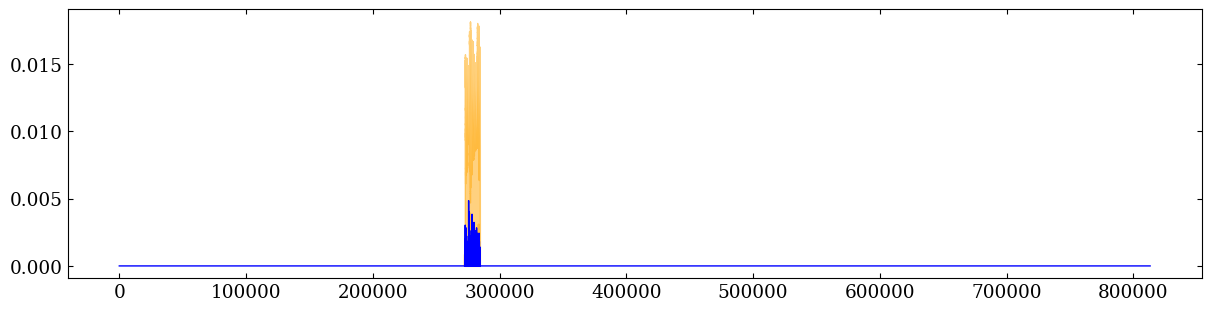

In [6]:
fiber.calc_energy_landscape(octamer=True, amplitude=0.05, period=10.47866367, chemical_potential=5)
dyad, occ = compute_vanderlick(fiber.energy)
print(np.sum(dyad_density))


plot.new(fig_size=(12, 3), nrows = 1, ncols=1)
panel = plot.panels[0]

panel.plot(fiber.index, dyad/np.sum(dyad), color="orange", alpha=0.5, label="Simulated occupancy (Vanderlick)")
panel.plot(dyad_density, label="Occupancy cleavage data", color="blue", linewidth=1)
panel.fill_between(fiber.index, occ/np.sum(dyad), color="orange", alpha=0.5)
panel.fill_between(fiber.index, occupancy_density, color="blue", alpha=0.5)
panel.set_xlim(locus_start+1000, locus_end-1000)
panel.set_ylim(0, 0.05)

KeyboardInterrupt: 

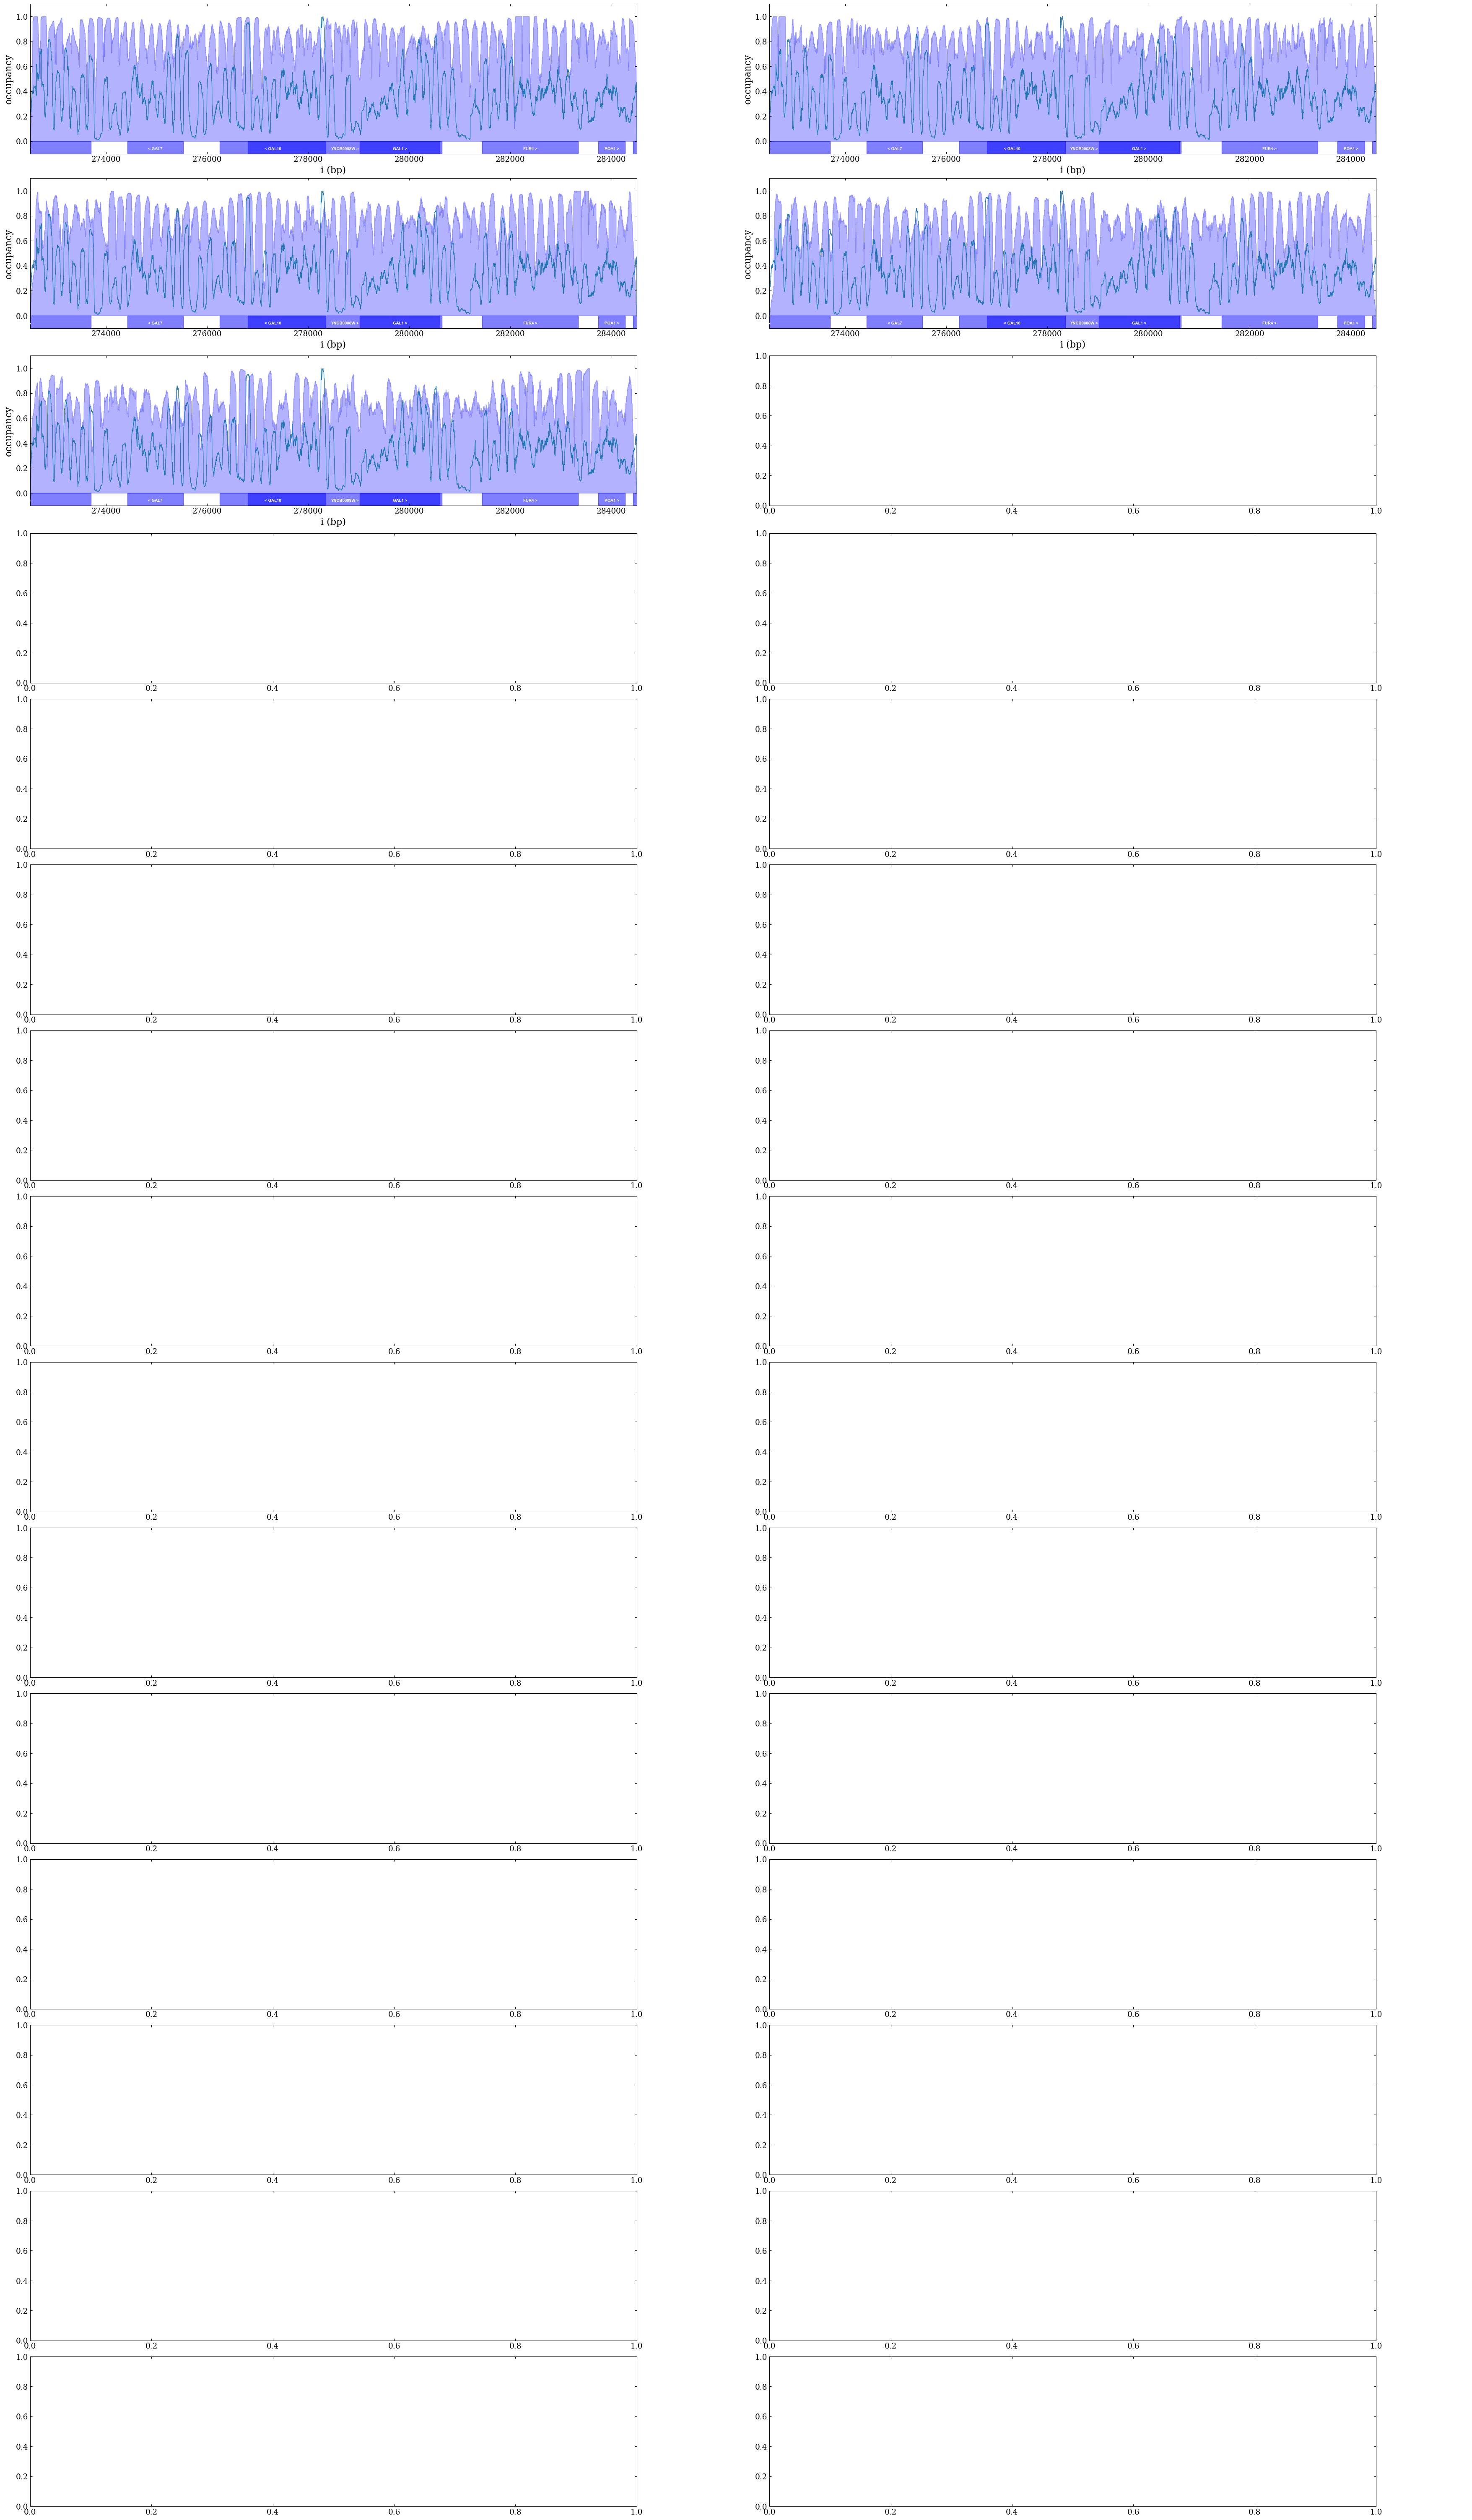

In [65]:
mus = np.linspace(2, 5, num=6)
periods = np.linspace(9.5, 10.5, num=5)

plot.new(fig_size=(7*len(periods), 10*len(mus)), nrows = 15, ncols=2)
for i, panel in enumerate(plot.panels):
        fiber.calc_energy_landscape(octamer=True, amplitude=0.06, period=periods[i%5], chemical_potential=mus[i%6])
        dyads, occ = compute_vanderlick(fiber.energy)
        dyad_amount = np.sum(dyads)
        #dyad_amount = dyad_amount * len(values_dyad_1)//length
        panel.plot(normalize(selector(occupancy_density,locus_start,locus_end)*dyad_amount), label=f"Simulated occupancy, mu={mus[i%6]:.2f}, period={periods[i%5]:.2f}", linewidth=1)
        plot_sequence(panel, fiber, energy=False, orfs=True)

np.float64(68.2083629243238)

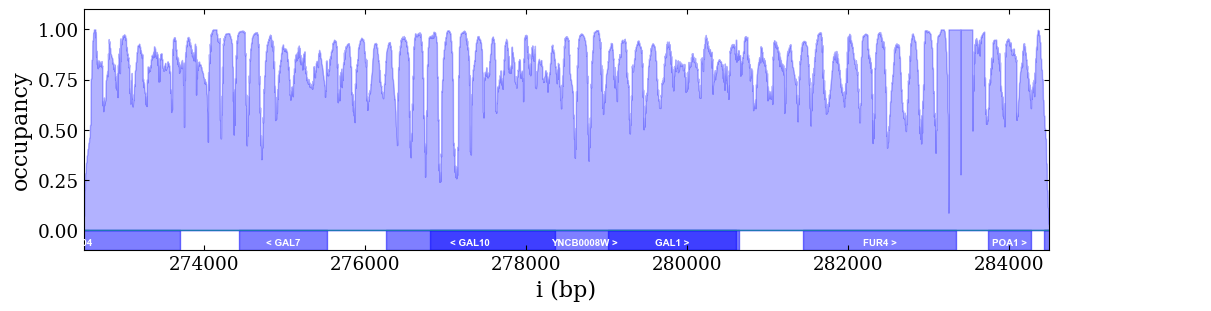

In [50]:
plot.new(fig_size=(12, 3), nrows = 1, ncols=1)
panel = plot.panels[0]

fiber.calc_energy_landscape(octamer=True, amplitude=0.06, period=10, chemical_potential=2)
dyads, occ = compute_vanderlick(fiber.energy)
dyad_amount = np.sum(dyads)
#dyad_amount = dyad_amount * len(values_dyad_1)//length
panel.plot(selector(occupancy_density,locus_start,locus_end), label=f"Simulated occupancy, mu=2, period=10", linewidth=1)
plot_sequence(panel, fiber, energy=False, orfs=True)
dyad_amount

In [ ]:

from scipy.optimize import differential_evolution
import numpy as np

def loss(params, fiber, target_occupancy):
    period, amplitude, chemical_potential = params
    
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    
    return np.sum((fiber.occupancy[1000:10000] - target_occupancy[1000:10000])**2)

In [44]:
bounds = [
    (9.5, 10.5),    # period — near 10 bp helical repeat
    (0.05, 0.1),   # amplitude — as per your docstring
    (2.0, 5.0),    # chemical_potential — as per your docstring
]

result = differential_evolution(
    loss, bounds, args=(fiber, target_occupancy),
    maxiter=100,   # down from 500
    popsize=5,     # down from 15
    tol=1e-4,      # loosen tolerance
    seed=42,
    disp=True,
)

period_fit, amplitude_fit, mu_fit = result.x

differential_evolution step 1: f(x)= 1643.0560571528458
differential_evolution step 2: f(x)= 1455.929810301267
differential_evolution step 3: f(x)= 1437.8213666709335
differential_evolution step 4: f(x)= 1437.8213666709335
differential_evolution step 5: f(x)= 1368.2649109189629
differential_evolution step 6: f(x)= 1323.40969215664
differential_evolution step 7: f(x)= 1323.40969215664
differential_evolution step 8: f(x)= 1323.40969215664
differential_evolution step 9: f(x)= 1323.40969215664
differential_evolution step 10: f(x)= 1301.9706752869106
differential_evolution step 11: f(x)= 1293.019618416914
differential_evolution step 12: f(x)= 1269.493748893545
differential_evolution step 13: f(x)= 1269.493748893545
differential_evolution step 14: f(x)= 1268.5497157271914
differential_evolution step 15: f(x)= 1252.4130107682565
differential_evolution step 16: f(x)= 1249.8064583694052
differential_evolution step 17: f(x)= 1249.8064583694052
differential_evolution step 18: f(x)= 1249.806458369

In [46]:
result.x

array([10.47866367,  0.05      ,  5.        ])

In [41]:
fiber.calc_energy_landscape(octamer=True, amplitude=0.06, period=10, chemical_potential=2)

In [42]:
fiber.occupancy[1000:10000]

array([0.81827229, 0.81925374, 0.81896644, ..., 0.47081441, 0.50601568,
       0.51794508], shape=(9000,))